In [1]:

# =====================================
# 1. SETUP
# =====================================
!pip install ultralytics opencv-python-headless pycocotools matplotlib

  Using cached polars-1.34.0-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.17-py3-none-any.whl.metadata (14 kB)
  Using cached polars_runtime_32-1.34.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.7 MB/s  0:00:00
Using cached ultralytics_thop-2.0.17-py3-none-any.whl (28 kB)
Using cached polars-1.34.0-py3-none-any.whl (772 kB)
Using cached polars_runtime_32-1.34.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (40.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ultralytics] [ultralytics]me-32]


In [1]:

import os, cv2, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO
from pycocotools.coco import COCO


In [6]:
# # =====================================
# # 2. DATA PREPARATION: COCO -> YOLO
# # =====================================

# def coco_to_yolo_seg(coco_json, img_dir, out_dir):
#     """
#     Convert COCO segmentation annotations to YOLOv8 format.
#     """
#     os.makedirs(out_dir, exist_ok=True)
#     coco = COCO(coco_json)
#     img_ids = coco.getImgIds()

#     for img_id in img_ids:
#         info = coco.loadImgs(img_id)[0]
#         img_w, img_h = info['width'], info['height']
#         img_filename = info['file_name']
#         anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))

#         label_path = os.path.join(out_dir, os.path.splitext(img_filename)[0] + ".txt")
#         with open(label_path, "w") as f:
#             for ann in anns:
#                 if "segmentation" not in ann: 
#                     continue
#                 seg = ann['segmentation'][0]
#                 cat_id = ann['category_id']  # 0=blastomere, 1=fragment

#                 # polygon -> normalized points
#                 norm = []
#                 for i in range(0, len(seg), 2):
#                     x = seg[i] / img_w
#                     y = seg[i+1] / img_h
#                     norm.append(f"{x:.6f} {y:.6f}")

#                 x,y,w,h = ann['bbox']
#                 x_c, y_c = (x+w/2)/img_w, (y+h/2)/img_h
#                 w_n, h_n = w/img_w, h/img_h

#                 line = f"{cat_id} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f} " + " ".join(norm) + "\n"
#                 f.write(line)

# # Example: convert train/val
# coco_to_yolo_seg("CleavageEmbryov1.1/annotations/instances_train.json", "CleavageEmbryov1.1/images/train", "CleavageEmbryov1.1/labels/train")
# coco_to_yolo_seg("CleavageEmbryov1.1/annotations/instances_val.json", "CleavageEmbryov1.1/images/val", "CleavageEmbryov1.1/labels/val")

loading annotations into memory...
Done (t=0.13s)
creating index...
index created!


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


In [2]:
# =====================================
# 3. DATASET CONFIG FILE
# =====================================
yaml_path = "cleavage.yaml"
with open(yaml_path, "w") as f:
    f.write("""path: .
train: CleavageEmbryov1.1/images/train
val: CleavageEmbryov1.1/images/val
names:
  0: blastomere
  1: fragment
""")
print(open(yaml_path).read())


path: .
train: CleavageEmbryov1.1/images/train
val: CleavageEmbryov1.1/images/val
names:
  0: blastomere
  1: fragment



In [8]:
# =====================================
# 4. TRAIN YOLOv8
# =====================================
# Small model for speed: yolov8n-seg
!yolo task=segment mode=train model=yolov8n-seg.pt data=cleavage.yaml epochs=100 imgsz=640 batch=16

Ultralytics 8.3.221 🚀 Python-3.13.7 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22478MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cleavage.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretr


image 1/1 /home/ubuntu/projects/embryo_classification/CleavageEmbryov1.1/images/val/20230304-17097-3-F0-157.jpg: 640x640 3 fragments, 5.7ms
Speed: 2.3ms preprocess, 5.7ms inference, 15.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /home/ubuntu/projects/embryo_classification/runs/segment/predict8


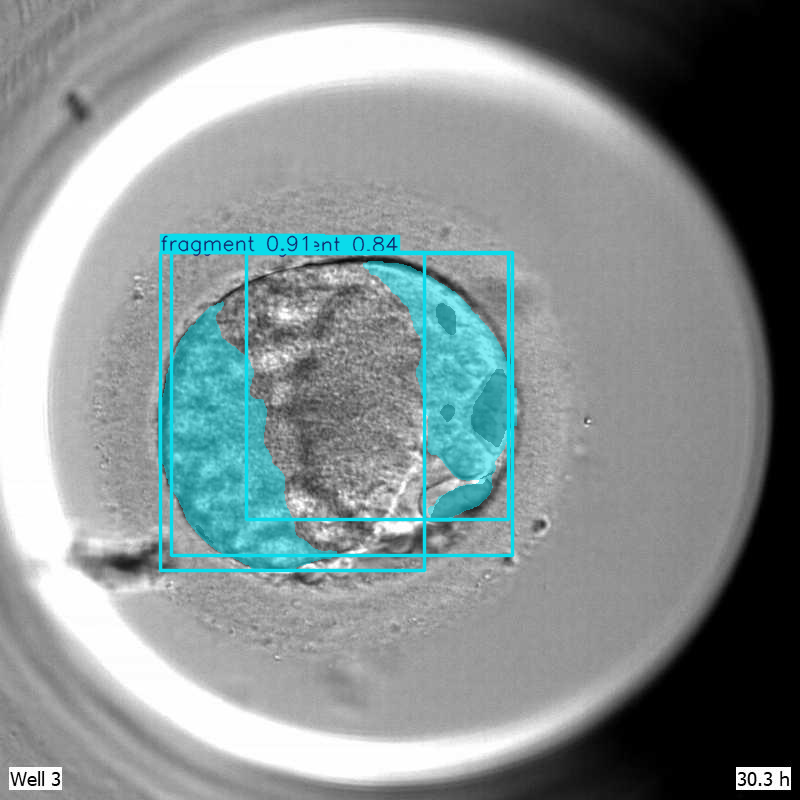

In [3]:
# =====================================
# 5. INFERENCE
# =====================================
model = YOLO("runs/segment/train/weights/best.pt")

# run on a single image
result = model("CleavageEmbryov1.1/images/val/20230304-17097-3-F0-157.jpg", save=True, imgsz=640)[0]
result.show()


In [7]:
# =====================================
# 6. GRADING FUNCTION
# =====================================

def grade_day3(result):
    """
    Compute Day-3 embryo grading from YOLO segmentation result.
    """
    masks = result.masks.xy  # polygon coordinates per instance
    classes = result.boxes.cls.cpu().numpy().astype(int)

    cell_areas, frag_areas = [], []
    for mask, c in zip(masks, classes):
        poly = np.array(mask, dtype=np.int32)
        area = cv2.contourArea(poly)
        if c==0: cell_areas.append(area)
        else: frag_areas.append(area)

    # Metrics
    cell_count = len(cell_areas)
    frag_pct = 100 * sum(frag_areas) / (sum(frag_areas) + sum(cell_areas) + 1e-6)
    cov = 100*np.std(cell_areas)/(np.mean(cell_areas)+1e-6) if cell_areas else 999

    # Scoring rubric
    cell_score = 40 if cell_count==8 else 35 if 7<=cell_count<=9 else 25 if cell_count in (6,10) else 10
    frag_score = 30 if frag_pct<10 else 20 if frag_pct<25 else 10 if frag_pct<=50 else 0
    sym_score  = 20 if cov<=15 else 12 if cov<=30 else 4
    grade = max(0, cell_score + frag_score + sym_score)
    category = "Good" if grade>=75 else "Fair" if grade>=50 else "Poor"

    return {
        "cell_count": cell_count,
        "fragmentation_pct": frag_pct,
        "symmetry_cov": cov,
        "grade": grade,
        "category": category
    }

graded = grade_day3(result)
graded


{'cell_count': 0,
 'fragmentation_pct': 99.99999999768417,
 'symmetry_cov': 999,
 'grade': 14,
 'category': 'Poor'}

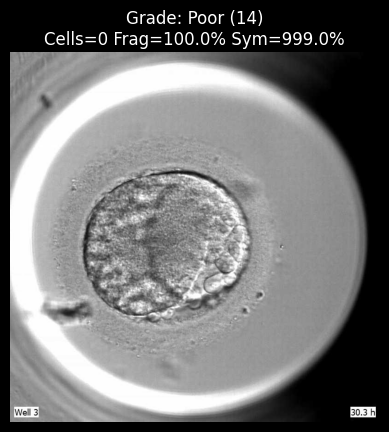

In [8]:
# =====================================
# 7. VISUALIZATION
# =====================================
img = cv2.imread("CleavageEmbryov1.1/images/val/20230304-17097-3-F0-157.jpg")[...,::-1]
plt.imshow(img)
plt.title(f"Grade: {graded['category']} ({graded['grade']})\nCells={graded['cell_count']} Frag={graded['fragmentation_pct']:.1f}% Sym={graded['symmetry_cov']:.1f}%")
plt.axis("off")
plt.show()


In [4]:
from ultralytics import YOLO

# Load trained model
model = YOLO("runs/segment/train/weights/best.pt")

# Evaluate on validation set
metrics = model.val(split="val", imgsz=640, batch=16)

print("Segmentation Report")
print(f"mAP@0.5:     {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")

Ultralytics 8.3.221 🚀 Python-3.13.7 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22478MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,454 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 80.8±4.4 MB/s, size: 89.4 KB)
val: Scanning /home/ubuntu/projects/embryo_classification/CleavageEmbryov1.1/labels/val.cache... 316 images, 0 backgrounds, 285 corrupt: 100% ━━━━━━━━━━━━ 316/316 858.4Kit/s 0.0s
val: /home/ubuntu/projects/embryo_classification/CleavageEmbryov1.1/images/val/20230304-17097-10-FX0-216.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: /home/ubuntu/projects/embryo_classification/CleavageEmbryov1.1/images/val/20230304-17097-10-FX0-218.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: /home/ubuntu/projects/embryo_classification/CleavageEmbryov1.1/images/val/20230304-17097-3-F0-157.jpg: ignoring corrupt image/label: Lab

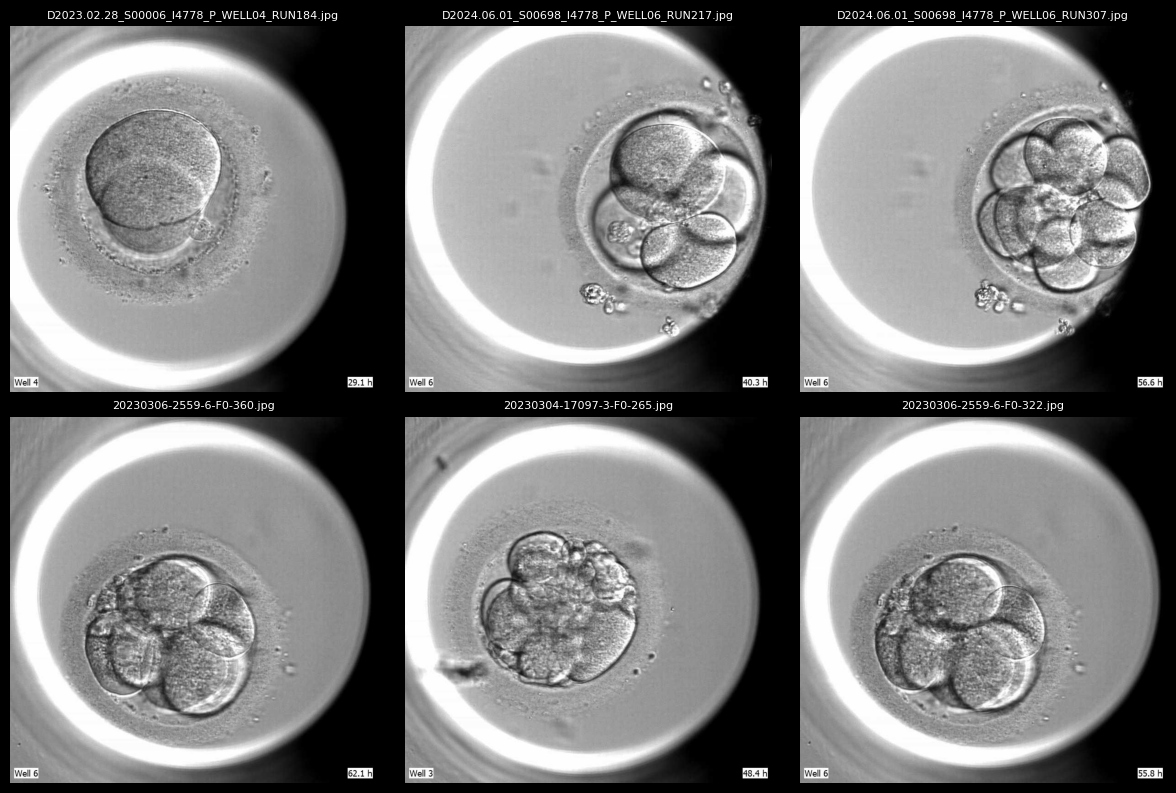

In [18]:
import matplotlib.pyplot as plt
import cv2, os

# Show some random images from the dataset
val_dir = "CleavageEmbryov1.1/images/val"  # adjust if needed
samples = os.listdir(val_dir)[:6]  # first 6 images

plt.figure(figsize=(12,8))
for i, img_file in enumerate(samples):
    img = cv2.imread(os.path.join(val_dir, img_file))[...,::-1]  # BGR->RGB
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_file, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [11]:
import cv2, os, numpy as np
import matplotlib.pyplot as plt

def compute_iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter + 1e-6)

def compare_pred_gt_headless(img_path, result, label_path):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # preds
    preds = result.boxes.xyxy.cpu().numpy()
    pred_classes = result.boxes.cls.cpu().numpy().astype(int)

    # GT
    gt_boxes, gt_classes = [], []
    with open(label_path, "r") as f:
        for line in f:
            parts = list(map(float, line.split()))
            cls, xc, yc, bw, bh = parts[:5]
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            gt_boxes.append([x1, y1, x2, y2])
            gt_classes.append(int(cls))

    # # IoU per prediction (best GT)
    ious = []
    for pbox in preds:
        best = 0
        for gt in gt_boxes:
            best = max(best, compute_iou(pbox, gt))
        ious.append(best)
    mean_iou = np.mean(ious) if ious else 0.0
    print(f"Mean IoU (pred → best GT): {mean_iou:.3f}")

    # draw
    draw = img.copy()
    # # predicted = green
    # for (x1,y1,x2,y2), c in zip(preds, pred_classes):
    #     cv2.rectangle(draw, (int(x1),int(y1)), (int(x2),int(y2)), (0,255,0), 2)
    #     cv2.putText(draw, f"pred:{c}", (int(x1), int(y1)-5),
    #                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    # GT = red
    for (x1,y1,x2,y2), c in zip(gt_boxes, gt_classes):
        cv2.rectangle(draw, (x1,y1), (x2,y2), (255,0,0), 2)
        cv2.putText(draw, f"pred:{c}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

    # BGR → RGB for matplotlib
    draw = cv2.cvtColor(draw, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(draw)
    plt.title(f"Prediction")
    # plt.title(f"mean IoU: {mean_iou:.3f}")
    plt.axis("off")
    plt.show()

    # return mean_iou


Mean IoU (pred → best GT): 0.789


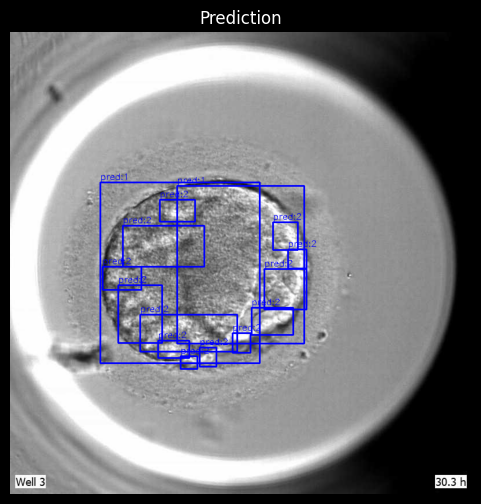

In [12]:
img_path = "CleavageEmbryov1.1/images/val/20230304-17097-3-F0-157.jpg"
label_path = "CleavageEmbryov1.1/labels/val/20230304-17097-3-F0-157.txt"
res = model(img_path, imgsz=640, verbose=False)[0]
compare_pred_gt_headless(img_path, res, label_path)

In [ ]:
import sys
sys.exit()